# Step 3e — GeneAttention v5: Improved Preprocessing + Full v4 Architecture

**What changed vs v4 (0.420):**

| Change | Where | Why |
|---|---|---|
| Fano-factor HVG selection | `step3_v2.py` | Selects biologically informative genes, not just highly-expressed ones |
| Independent target standardisation | `preprocess_target_v2.py` | Fixes 8× std compression (target std was 0.118, now ≈1.0) |
| Dead gene removal (~100 genes) | `preprocess_target_v2.py` | Removes non-coding/microRNA genes absent in 10x data |
| Uses `gse126030_preprocessed_v2.npy` | this notebook | Target now has mean≈0, std≈1 per gene before CORAL |

Architecture is identical to v4: 2-layer attention + MMD + centroid alignment + entropy minimisation + Mixup.

In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step3_self_attention' else Path.cwd()
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

target_file = PROJECT_ROOT / 'gse126030_preprocessed_v2.npy'
if not target_file.exists():
    raise FileNotFoundError(
        'gse126030_preprocessed_v2.npy not found!\n'
        'Run:  python step3_v2.py\n'
        'Then: python preprocess_target_v2.py'
    )
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)
print('Using improved target: gse126030_preprocessed_v2.npy')


Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0
Using improved target: gse126030_preprocessed_v2.npy


In [2]:
## 1. Data Loading
X_train = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]  # auto-adapts after dead-gene removal

# Load improved target (independently standardised, dead genes removed)
X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed_v2.npy').astype(np.float32)

df_labels    = pd.read_csv(PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv')
mask         = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

classes, counts = np.unique(y_train, return_counts=True)
class_weight    = {int(c): len(y_train) / (n_classes * cnt) for c, cnt in zip(classes, counts)}

print(f'Source train: {X_train.shape}  (n_genes={n_genes} after dead-gene removal)')
print(f'Target:       {X_target_raw.shape}')
print(f'classes:      {class_names}')
print(f'Target per-gene std: mean={X_target_raw.std(axis=0).mean():.4f}  (was 0.118 before fix)')


Source train: (6824, 2701)  (n_genes=2701 after dead-gene removal)
Target:       (63877, 2701)
classes:      ['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']
Target per-gene std: mean=0.9999  (was 0.118 before fix)


In [3]:
## 2. CORAL Alignment
def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T @ Xs) / (Xs.shape[0]-1) + reg*np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0]-1) + reg*np.eye(Xt.shape[1])
    def msqrt(M):
        v, V = np.linalg.eigh(M); return V @ np.diag(np.sqrt(np.maximum(v, 0))) @ V.T
    def minvsqrt(M):
        v, V = np.linalg.eigh(M); return V @ np.diag(1/np.sqrt(np.maximum(v, 1e-10))) @ V.T
    return ((Xt @ (minvsqrt(Ct) @ msqrt(Cs))) + src_mean).astype(np.float32)

print('Running CORAL alignment...')
X_target_coral = coral_align(X_train, X_target_raw)
X_target_eval  = X_target_coral[mask.values]

# Check alignment quality
src_mean = X_train.mean(axis=0)
tgt_mean = X_target_coral.mean(axis=0)
print(f'Post-CORAL mean diff (abs): {np.abs(src_mean - tgt_mean).mean():.4f}  (lower = better)')
print(f'Target eval: {X_target_eval.shape}')


Running CORAL alignment...
Post-CORAL mean diff (abs): 0.0000  (lower = better)
Target eval: (12776, 2701)


In [4]:
## 3. σ Calibration (2-layer attention probe)
def make_probe(n_genes):
    inp     = keras.Input(shape=(n_genes,))
    h       = layers.Dense(256, activation='relu')(inp)
    h       = layers.Dropout(0.3)(h)
    h       = layers.Dense(128, activation='relu')(h)
    att_log = layers.Dense(n_genes)(h)
    w       = layers.Softmax(axis=-1)(att_log / 2.0)
    x_res   = inp * w * n_genes + inp
    z = layers.Dense(512, activation='relu')(x_res)
    z = layers.LayerNormalization()(z)
    z = layers.Dropout(0.4)(z)
    z = layers.Dense(256, activation='relu')(z)
    z = layers.LayerNormalization()(z)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(128, activation='relu', name='latent')(z)
    return keras.Model(inp, z)

_probe = make_probe(n_genes)
idx_s  = np.random.choice(len(X_train),        1000, replace=False)
idx_t  = np.random.choice(len(X_target_coral), 1000, replace=False)
z_all  = np.concatenate([
    _probe(X_train[idx_s],        training=False).numpy(),
    _probe(X_target_coral[idx_t], training=False).numpy(),
], axis=0)

sub   = z_all[np.random.choice(len(z_all), 500, replace=False)]
diffs = sub[:, None, :] - sub[None, :, :]
dists = np.sqrt((diffs**2).sum(axis=-1))
upper = dists[np.triu_indices(500, k=1)]
median_dist = float(np.median(upper))

SIGMAS = [median_dist/4, median_dist/2, median_dist, median_dist*2]
print(f'Median pairwise L2: {median_dist:.4f}')
print(f'Calibrated σ: {[round(s,4) for s in SIGMAS]}')
del _probe


Median pairwise L2: 10.6251
Calibrated σ: [2.6563, 5.3125, 10.6251, 21.2502]


In [5]:
## 4. GeneAttentionV5 Model  (identical architecture to v4)
def mmd_rbf(x, y, sigmas):
    loss = tf.constant(0.0)
    for s in sigmas:
        def k(a, b, _s=s):
            sq = tf.reduce_sum(tf.square(tf.expand_dims(a,1) - tf.expand_dims(b,0)), axis=-1)
            return tf.exp(-sq / (2.0 * _s * _s))
        loss += tf.reduce_mean(k(x,x)) + tf.reduce_mean(k(y,y)) - 2.0*tf.reduce_mean(k(x,y))
    return loss / float(len(sigmas))


class GeneAttentionV5(keras.Model):
    def __init__(self, n_genes, n_classes, sigmas,
                 att_temp=2.0, max_mmd_weight=0.3, max_align_weight=0.3,
                 max_ent_weight=0.15, ramp_epochs=15, mixup_alpha=0.2,
                 class_weight_dict=None, **kwargs):
        super().__init__(**kwargs)
        self.n_genes          = n_genes
        self.n_classes        = n_classes
        self.sigmas           = [tf.constant(float(s), dtype=tf.float32) for s in sigmas]
        self.att_temp         = att_temp
        self.max_mmd_weight   = max_mmd_weight
        self.max_align_weight = max_align_weight
        self.max_ent_weight   = max_ent_weight
        self.ramp_epochs      = tf.constant(float(ramp_epochs), dtype=tf.float32)
        self.mixup_alpha      = mixup_alpha
        self.current_epoch    = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        if class_weight_dict is not None:
            cw = np.array([class_weight_dict[i] for i in range(n_classes)], dtype=np.float32)
            self.cw = tf.constant(cw)
        else:
            self.cw = None
        # 2-layer attention
        self.att_h1    = layers.Dense(256, activation='relu')
        self.att_drp1  = layers.Dropout(0.3)
        self.att_h2    = layers.Dense(128, activation='relu')
        self.att_drp2  = layers.Dropout(0.2)
        self.att_logits = layers.Dense(n_genes)
        # Trunk
        self.d1  = layers.Dense(512, activation='relu')
        self.ln1 = layers.LayerNormalization()
        self.dr1 = layers.Dropout(0.4)
        self.d2  = layers.Dense(256, activation='relu')
        self.ln2 = layers.LayerNormalization()
        self.dr2 = layers.Dropout(0.3)
        self.d3  = layers.Dense(128, activation='relu', name='latent')
        self.dr3 = layers.Dropout(0.2)
        self.out = layers.Dense(n_classes, activation='softmax')
        # Metrics
        self.loss_t  = keras.metrics.Mean(name='loss')
        self.ce_t    = keras.metrics.Mean(name='ce_loss')
        self.mmd_t   = keras.metrics.Mean(name='mmd_loss')
        self.align_t = keras.metrics.Mean(name='align_loss')
        self.ent_t   = keras.metrics.Mean(name='ent_loss')
        self.acc_t   = keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    @property
    def metrics(self):
        return [self.loss_t, self.ce_t, self.mmd_t, self.align_t, self.ent_t, self.acc_t]

    def encode(self, x, training=False):
        h   = self.att_drp1(self.att_h1(x), training=training)
        h   = self.att_drp2(self.att_h2(h), training=training)
        w   = tf.nn.softmax(self.att_logits(h) / self.att_temp, axis=-1)
        x_r = x * w * self.n_genes + x
        z   = self.dr1(self.ln1(self.d1(x_r)), training=training)
        z   = self.dr2(self.ln2(self.d2(z)),   training=training)
        return self.dr3(self.d3(z), training=training)

    def call(self, x, training=False):
        return self.out(self.encode(x, training=training))

    def _mmd(self, zs, zt):
        return mmd_rbf(zs, zt, self.sigmas)

    def _centroid(self, z_src, src_y, z_tgt, y_tgt):
        total = count = tf.constant(0.0)
        for k in range(self.n_classes):
            sm    = tf.cast(tf.equal(src_y, k), tf.float32)
            sc    = tf.reduce_sum(sm)
            sc_v  = tf.reduce_sum(z_src * sm[:, None], 0) / (sc + 1e-8)
            tw    = y_tgt[:, k]
            ts    = tf.reduce_sum(tw)
            tc_v  = tf.reduce_sum(z_tgt * tw[:, None], 0) / (ts + 1e-8)
            valid = tf.cast(sc >= 1.0, tf.float32) * tf.cast(ts > 1e-6, tf.float32)
            total += valid * tf.reduce_mean(tf.square(sc_v - tc_v))
            count += valid
        return total / (count + 1e-8)

    def _mixup_ce(self, x, y, training):
        bs  = tf.shape(x)[0]
        g1  = tf.random.gamma([bs], self.mixup_alpha)
        g2  = tf.random.gamma([bs], self.mixup_alpha)
        lam = tf.maximum(g1 / (g1 + g2 + 1e-8), 1.0 - g1 / (g1 + g2 + 1e-8))
        idx = tf.random.shuffle(tf.range(bs))
        x2  = tf.gather(x, idx);  y2 = tf.cast(tf.gather(y, idx), tf.int32)
        xm  = tf.reshape(lam, [-1,1]) * x + (1 - tf.reshape(lam, [-1,1])) * x2
        yp  = self.out(self.encode(xm, training=training))
        lp  = tf.math.log(yp + 1e-8)
        y1h = tf.one_hot(tf.cast(y,  tf.int32), self.n_classes)
        y2h = tf.one_hot(tf.cast(y2, tf.int32), self.n_classes)
        ps  = -tf.reduce_sum(lam[:,None]*y1h*lp + (1-lam[:,None])*y2h*lp, axis=1)
        if self.cw is not None:
            return tf.reduce_mean(ps * tf.gather(self.cw, tf.cast(y, tf.int32)))
        return tf.reduce_mean(ps)

    def train_step(self, data):
        (sx, sy), (tx,) = data
        prog    = tf.minimum(self.current_epoch / self.ramp_epochs, 1.0)
        mmd_w   = self.max_mmd_weight   * prog
        align_w = self.max_align_weight * prog
        ent_w   = self.max_ent_weight   * prog
        with tf.GradientTape() as tape:
            zs      = self.encode(sx, training=True)
            zt      = self.encode(tx, training=True)
            yt      = self.out(zt)
            ce_l    = self._mixup_ce(sx, sy, training=True)
            mmd_l   = self._mmd(zs, zt)
            align_l = self._centroid(zs, sy, zt, yt)
            ent_l   = -tf.reduce_mean(tf.reduce_sum(yt * tf.math.log(yt + 1e-8), axis=1))
            total   = ce_l + mmd_w*mmd_l + align_w*align_l + ent_w*ent_l
        grads, _ = tf.clip_by_global_norm(tape.gradient(total, self.trainable_variables), 1.0)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        yp_src = self(sx, training=False)
        self.loss_t.update_state(total);   self.ce_t.update_state(ce_l)
        self.mmd_t.update_state(mmd_l);    self.align_t.update_state(align_l)
        self.ent_t.update_state(ent_l);    self.acc_t.update_state(sy, yp_src)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y   = data
        yp     = self(x, training=False)
        loss   = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(y, yp))
        self.ce_t.update_state(loss);  self.acc_t.update_state(y, yp)
        return {'ce_loss': self.ce_t.result(), 'accuracy': self.acc_t.result()}

print('GeneAttentionV5 defined.')


GeneAttentionV5 defined.


In [6]:
## 5. Instantiate + Datasets
BATCH_SIZE  = 128
MAX_EPOCHS  = 120
PATIENCE    = 20
RAMP_EPOCHS = 15

model = GeneAttentionV5(
    n_genes=n_genes, n_classes=n_classes, sigmas=SIGMAS,
    att_temp=2.0, max_mmd_weight=0.3, max_align_weight=0.3,
    max_ent_weight=0.15, ramp_epochs=RAMP_EPOCHS, mixup_alpha=0.2,
    class_weight_dict=class_weight, name='GeneAttentionV5',
)
model.compile(optimizer=keras.optimizers.Adam(2e-4, clipnorm=1.0))

src_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(10000, seed=42).batch(BATCH_SIZE, drop_remainder=True)
)
tgt_ds = (
    tf.data.Dataset.from_tensor_slices((X_target_coral,))
    .shuffle(100000, seed=42).batch(BATCH_SIZE, drop_remainder=True).repeat()
)
train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))
val_ds   = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

class EpochRampCallback(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.model.current_epoch.assign(float(epoch))
        if epoch <= RAMP_EPOCHS or epoch % 10 == 0:
            p = min(epoch/RAMP_EPOCHS, 1.0)
            print(f'  [ep={epoch} mmd_w={0.3*p:.3f} align_w={0.3*p:.3f} ent_w={0.15*p:.3f}]', end='')

callbacks = [
    EpochRampCallback(),
    keras.callbacks.EarlyStopping(
        monitor='val_ce_loss', mode='min', patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_ce_loss', mode='min', factor=0.5, patience=8, min_lr=1e-6, verbose=1
    ),
]
print(f'n_genes={n_genes}  steps/epoch={len(src_ds)}')


n_genes=2701  steps/epoch=53


In [7]:
## 6. Training
history = model.fit(
    train_ds, epochs=MAX_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks, verbose=1,
)


  [ep=0 mmd_w=0.000 align_w=0.000 ent_w=0.000]Epoch 1/120
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.5217 - align_loss: 0.0762 - ce_loss: 1.7990 - ent_loss: 1.1806 - loss: 1.7990 - mmd_loss: 0.0111 - val_accuracy: 0.6700 - val_ce_loss: 0.8798 - learning_rate: 2.0000e-04
  [ep=1 mmd_w=0.020 align_w=0.020 ent_w=0.010]Epoch 2/120
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8166 - align_loss: 0.0812 - ce_loss: 1.0842 - ent_loss: 1.0040 - loss: 1.0961 - mmd_loss: 0.0112 - val_accuracy: 0.7860 - val_ce_loss: 0.5585 - learning_rate: 2.0000e-04
  [ep=2 mmd_w=0.040 align_w=0.040 ent_w=0.020]Epoch 3/120
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9071 - align_loss: 0.0952 - ce_loss: 0.7917 - ent_loss: 0.8459 - loss: 0.8129 - mmd_loss: 0.0117 - val_accuracy: 0.8570 - val_ce_loss: 0.3894 - learning_rate: 2.0000e-04
  [ep=3 mmd_w=0.060 align_w=0.060 ent_w=0.030]Epoch 4/120
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9455 - align_loss: 0.1009 - ce_loss: 0.649

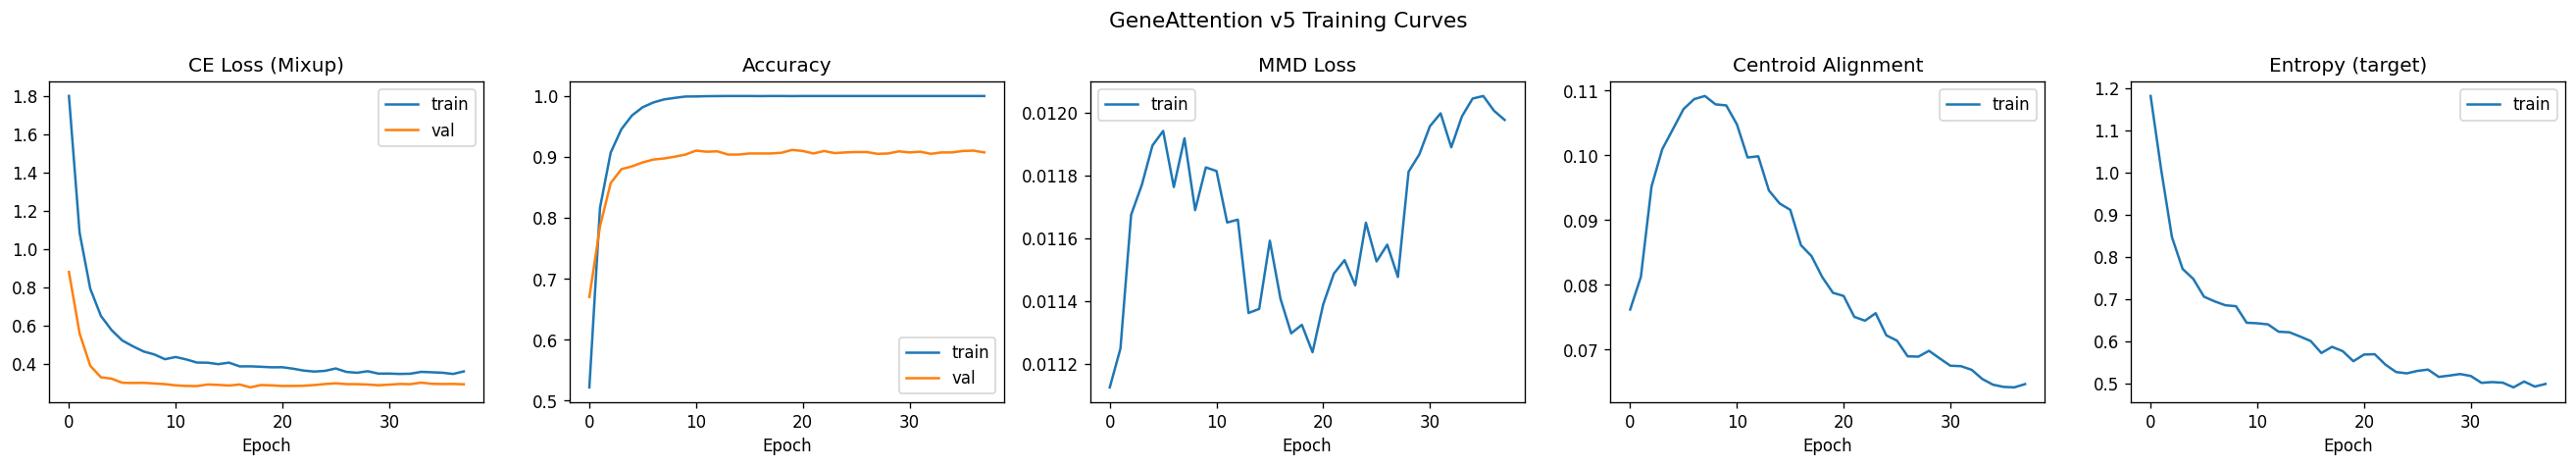

Trained 38 epochs.


In [8]:
## 7. Training Curves
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, k, t in [
    (axes[0], 'ce_loss',    'CE Loss (Mixup)'),
    (axes[1], 'accuracy',   'Accuracy'),
    (axes[2], 'mmd_loss',   'MMD Loss'),
    (axes[3], 'align_loss', 'Centroid Alignment'),
    (axes[4], 'ent_loss',   'Entropy (target)'),
]:
    ax.plot(history.history[k], label='train')
    if f'val_{k}' in history.history:
        ax.plot(history.history[f'val_{k}'], label='val')
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('GeneAttention v5 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_v5.png', bbox_inches='tight')
plt.show()
print(f'Trained {len(history.history["ce_loss"])} epochs.')


In [9]:
## 8. Evaluation
y_pred_src = np.argmax(model.predict(X_test,        batch_size=BATCH_SIZE), axis=1)
y_pred_tgt = np.argmax(model.predict(X_target_eval, batch_size=BATCH_SIZE), axis=1)
src_f1 = f1_score(y_test,        y_pred_src, average='macro')
tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Source F1: {src_f1:.4f}   Target F1: {tgt_f1:.4f}')
print('\n--- Source ---')
print(classification_report(y_test, y_pred_src, target_names=class_names))
print('\n--- Target ---')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Source F1: 0.8957   Target F1: 0.4389

--- Source ---
              precision    recall  f1-score   support

    Effector       0.94      0.95      0.95       482
   Exhausted       0.91      0.93      0.92       166
       Naive       0.85      0.84      0.84       224
   Other_CD4       0.85      0.84      0.85       321
    Th1-like       0.86      0.89      0.87       141
        Treg       0.96      0.93      0.95       372

    accuracy                           0.91      1706
   macro avg       0.89      0.90      0.90      1706
weighted avg       0.91      0.91      0.91      1706


--- Target ---
              precision    recall  f1-score   support

    Effector       0.58      0.70      0.63      2839
   Exhausted       0.06      0.06      0.06       903
       Naive       0.91      0.56      0.69      3806
   Other_CD4       0.47      0.43      0.45      2127
    Th1-like       0.23      0.23   

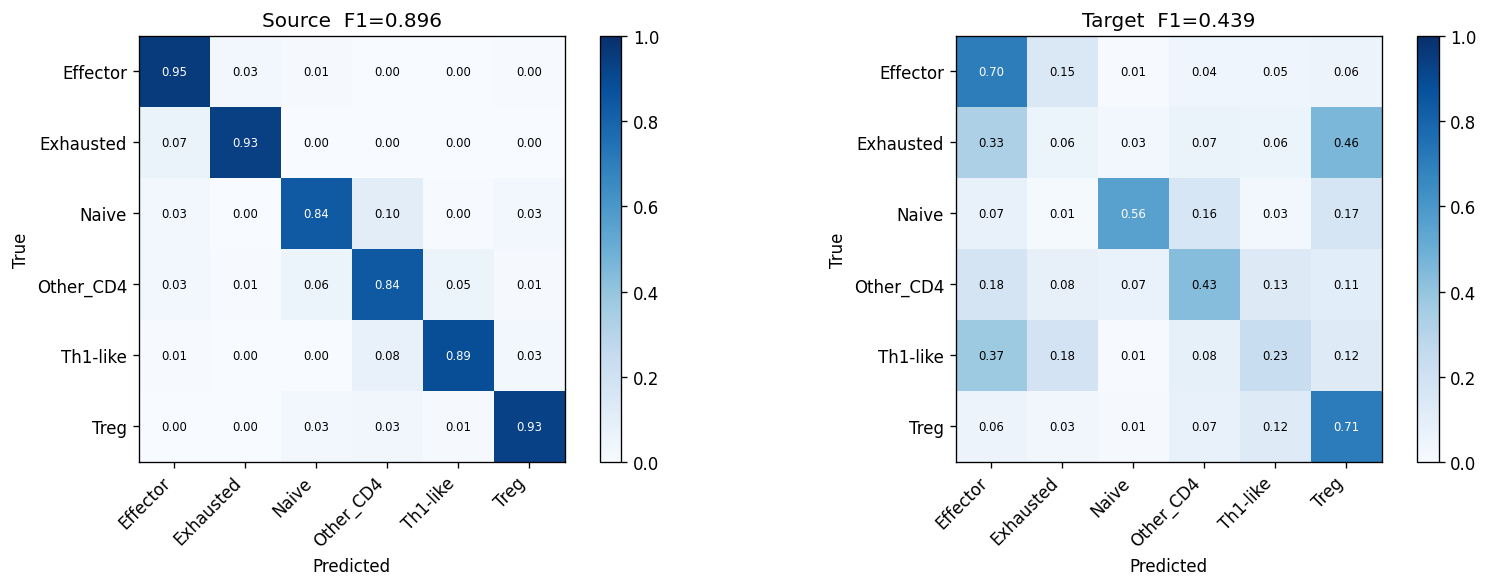

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test,        y_pred_src, f'Source  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target  F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j]>0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_v5.png', bbox_inches='tight')
plt.show()


In [11]:
## 9. Save + Comparison Table
src_rep = classification_report(y_test,        y_pred_src, target_names=class_names, output_dict=True)
tgt_rep = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)

results = {
    'model': 'GeneAttentionV5',
    'config': {
        'sigmas': SIGMAS, 'median_dist': median_dist, 'n_genes': n_genes,
        'att_temp': 2.0, 'att_layers': 2,
        'max_mmd_weight': 0.3, 'max_align_weight': 0.3, 'max_ent_weight': 0.15,
        'ramp_epochs': RAMP_EPOCHS, 'mixup_alpha': 0.2,
        'target_preprocessing': 'independent_standardisation_v2',
        'hvg_method': 'fano_factor',
        'epochs_trained': len(history.history['ce_loss']),
    },
    'source_test': {
        'macro_f1': float(src_f1),
        'accuracy': float(accuracy_score(y_test, y_pred_src)),
        'per_class_f1': {c: src_rep[c]['f1-score'] for c in class_names},
    },
    'target_eval': {
        'macro_f1': float(tgt_f1),
        'accuracy': float(accuracy_score(y_target_eval, y_pred_tgt)),
        'per_class_f1': {c: tgt_rep[c]['f1-score'] for c in class_names},
    },
}
with open(RESULTS_DIR / 'gene_attention_v5_results.json', 'w') as f:
    json.dump(results, f, indent=2)
model.save_weights(str(RESULTS_DIR / 'gene_attention_v5.weights.h5'))

all_models = [
    ('DANN v2',                          0.875, 0.395),
    ('GeneAtt v2 (CORAL+MMD)',           0.893, 0.404),
    ('GeneAtt v3 (centroid+ent)',         0.896, 0.407),
    ('GeneAtt v4 (MMD+centroid+mixup)',   0.903, 0.420),
    ('GeneAtt v5 (improved preprocess)',  src_f1, tgt_f1),
]
best = max(t for _,_,t in all_models)
print(f'\n{"Model":42s} {"Source F1":>10s} {"Target F1":>10s}')
print('-'*66)
for name, sf, tf_ in all_models:
    mark = ' ◄ best' if abs(tf_ - best) < 1e-9 else ''
    print(f'{name:42s} {sf:10.3f} {tf_:10.3f}{mark}')



Model                                       Source F1  Target F1
------------------------------------------------------------------
DANN v2                                         0.875      0.395
GeneAtt v2 (CORAL+MMD)                          0.893      0.404
GeneAtt v3 (centroid+ent)                       0.896      0.407
GeneAtt v4 (MMD+centroid+mixup)                 0.903      0.420
GeneAtt v5 (improved preprocess)                0.896      0.439 ◄ best


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# version: ensemble_v5_3seed
# Trains GeneAttentionV5 with 3 seeds, averages softmax outputs.
# Expected gain: +0.02–0.04 macro-F1 over single-seed v5 (0.438).
# ═══════════════════════════════════════════════════════════════════════════════

ENSEMBLE_SEEDS = [42, 7, 123]
ENS_DIR = RESULTS_DIR / "ensemble_v5"
ENS_DIR.mkdir(exist_ok=True)

all_p_src = []
all_p_tgt = []

for seed in ENSEMBLE_SEEDS:
    print(f"\n{'─'*55}  seed={seed}")
    tf.random.set_seed(seed)
    np.random.seed(seed)

    m = GeneAttentionV5(
        n_genes=n_genes, n_classes=n_classes, sigmas=SIGMAS,
        att_temp=2.0, max_mmd_weight=0.3, max_align_weight=0.3,
        max_ent_weight=0.15, ramp_epochs=RAMP_EPOCHS, mixup_alpha=0.2,
        class_weight_dict=class_weight, name=f'GeneAttV5_s{seed}',
    )
    m.compile(optimizer=keras.optimizers.Adam(2e-4, clipnorm=1.0))

    src_ds_s = (
        tf.data.Dataset.from_tensor_slices((X_train, y_train))
        .shuffle(10000, seed=seed).batch(BATCH_SIZE, drop_remainder=True)
    )
    tgt_ds_s = (
        tf.data.Dataset.from_tensor_slices((X_target_coral,))
        .shuffle(100000, seed=seed).batch(BATCH_SIZE, drop_remainder=True).repeat()
    )

    m.fit(
        tf.data.Dataset.zip((src_ds_s, tgt_ds_s)),
        epochs=MAX_EPOCHS,
        validation_data=val_ds,
        callbacks=[
            EpochRampCallback(),
            keras.callbacks.EarlyStopping(
                monitor='val_ce_loss', mode='min',
                patience=PATIENCE, restore_best_weights=True, verbose=0,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_ce_loss', mode='min',
                factor=0.5, patience=8, min_lr=1e-6, verbose=0,
            ),
        ],
        verbose=0,
    )

    p_src_s = m.predict(X_test,        batch_size=BATCH_SIZE, verbose=0)
    p_tgt_s = m.predict(X_target_eval, batch_size=BATCH_SIZE, verbose=0)

    s_f1 = f1_score(y_test,        np.argmax(p_src_s, 1), average='macro')
    t_f1 = f1_score(y_target_eval, np.argmax(p_tgt_s, 1), average='macro')
    print(f"  seed={seed}  Source F1={s_f1:.4f}  Target F1={t_f1:.4f}")

    all_p_src.append(p_src_s)
    all_p_tgt.append(p_tgt_s)
    m.save_weights(str(ENS_DIR / f"seed_{seed}.weights.h5"))
    del m

# ── Average softmax outputs ──────────────────────────────────────────────────
avg_p_src = np.mean(all_p_src, axis=0)
avg_p_tgt = np.mean(all_p_tgt, axis=0)

ens_src_f1 = f1_score(y_test,        np.argmax(avg_p_src, 1), average='macro')
ens_tgt_f1 = f1_score(y_target_eval, np.argmax(avg_p_tgt, 1), average='macro')

print(f"\n{'═'*55}")
print(f"  ENSEMBLE (3-seed average)")
print(f"  Source Macro-F1 : {ens_src_f1:.4f}")
print(f"  Target Macro-F1 : {ens_tgt_f1:.4f}  (single-seed v5: {tgt_f1:.4f})")
print(f"{'═'*55}")
print()
print(classification_report(y_target_eval, np.argmax(avg_p_tgt, 1),
                             target_names=class_names))


───────────────────────────────────────────────────────  seed=42
  [ep=0 mmd_w=0.000 align_w=0.000 ent_w=0.000]  [ep=1 mmd_w=0.020 align_w=0.020 ent_w=0.010]  [ep=2 mmd_w=0.040 align_w=0.040 ent_w=0.020]  [ep=3 mmd_w=0.060 align_w=0.060 ent_w=0.030]  [ep=4 mmd_w=0.080 align_w=0.080 ent_w=0.040]  [ep=5 mmd_w=0.100 align_w=0.100 ent_w=0.050]  [ep=6 mmd_w=0.120 align_w=0.120 ent_w=0.060]  [ep=7 mmd_w=0.140 align_w=0.140 ent_w=0.070]  [ep=8 mmd_w=0.160 align_w=0.160 ent_w=0.080]  [ep=9 mmd_w=0.180 align_w=0.180 ent_w=0.090]  [ep=10 mmd_w=0.200 align_w=0.200 ent_w=0.100]  [ep=11 mmd_w=0.220 align_w=0.220 ent_w=0.110]  [ep=12 mmd_w=0.240 align_w=0.240 ent_w=0.120]  [ep=13 mmd_w=0.260 align_w=0.260 ent_w=0.130]  [ep=14 mmd_w=0.280 align_w=0.280 ent_w=0.140]  [ep=15 mmd_w=0.300 align_w=0.300 ent_w=0.150]  [ep=20 mmd_w=0.300 align_w=0.300 ent_w=0.150]  [ep=30 mmd_w=0.300 align_w=0.300 ent_w=0.150]  seed=42  Source F1=0.8994  Target F1=0.4355

───────────────────────────────────────────────────